In [1]:
!pip install yfinance

In [2]:
# Import libraries

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
companies = {
    "NFLX": "1mo",
    "META": "3mo",
    "GOOGL": "6mo",
    "AAPL": "9mo",
    "AMZN": "1y"
}



In [35]:
# Create dictionary for all companies

all_companies = {}

In [36]:
# Download data for each company

for ticker, period in companies.items():

    stock = yf.Ticker(ticker)

    data = stock.history(period=period, interval="1d")

    # Extract Close price only
    close_prices = data["Close"]

    # Create DataFrame
    df_company = pd.DataFrame({
        "Date": close_prices.index,
        "Close": close_prices.values
    })

    df_company.reset_index(drop=True, inplace=True)

    # Save CSV file
    file_name = f"{ticker.lower()}_close_prices.csv"
    df_company.to_csv(file_name, index=False)

    # Reload saved file
    df_company = pd.read_csv(file_name)

    # Convert Date column
    df_company["Date"] = pd.to_datetime(df_company["Date"])

    # Save separate copy for each company
    all_companies[ticker] = df_company.copy()

/var/folders/w7/l2_gw_pn0kl678vgp9qb666m0000gn/T/ipykernel_10591/4294586135.py:28: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_company["Date"] = pd.to_datetime(df_company["Date"])
/var/folders/w7/l2_gw_pn0kl678vgp9qb666m0000gn/T/ipykernel_10591/4294586135.py:28: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_company["Date"] = pd.to_datetime(df_company["Date"])
/var/folders/w7/l2_gw_pn0kl678vgp9qb666m0000gn/T/ipykernel_10591/4294586135.py

In [37]:
# Show first rows for all companies

for ticker, df in all_companies.items():
    print("\n", ticker)
    print(df.head())



 NFLX
                       Date      Close
0 2026-03-30 00:00:00-04:00  92.970001
1 2026-03-31 00:00:00-04:00  96.150002
2 2026-04-01 00:00:00-04:00  95.550003
3 2026-04-02 00:00:00-04:00  98.660004
4 2026-04-06 00:00:00-04:00  98.930000

 META
                        Date       Close
0  2026-01-28 00:00:00-05:00  668.157898
1  2026-01-29 00:00:00-05:00  737.678406
2  2026-01-30 00:00:00-05:00  715.887085
3  2026-02-02 00:00:00-05:00  705.805664
4  2026-02-03 00:00:00-05:00  691.108276

 GOOGL
                        Date       Close
0  2025-10-28 00:00:00-04:00  267.107147
1  2025-10-29 00:00:00-04:00  274.197510
2  2025-10-30 00:00:00-04:00  281.098145
3  2025-10-31 00:00:00-04:00  280.808502
4  2025-11-03 00:00:00-05:00  283.335083

 AAPL
                        Date       Close
0  2025-07-28 00:00:00-04:00  213.400620
1  2025-07-29 00:00:00-04:00  210.629044
2  2025-07-30 00:00:00-04:00  208.415771
3  2025-07-31 00:00:00-04:00  206.940277
4  2025-08-01 00:00:00-04:00  201.766006

In [38]:
# Missing values

for ticker, df in all_companies.items():
    print("\nMissing values in", ticker)
    print(df["Close"].isnull().sum())



Missing values in NFLX
0

Missing values in META
0

Missing values in GOOGL
0

Missing values in AAPL
0

Missing values in AMZN
0


In [39]:
#Basic statistics

for ticker, df in all_companies.items():
    print("\nStatistics for", ticker)
    print(df["Close"].describe().round(2))



Statistics for NFLX
count     20.00
mean      98.25
std        5.27
min       91.37
25%       93.17
50%       97.99
75%      102.29
max      107.79
Name: Close, dtype: float64

Statistics for META
count     62.00
mean     640.20
std       41.99
min      525.72
25%      617.42
50%      648.44
75%      668.35
max      737.68
Name: Close, dtype: float64

Statistics for GOOGL
count    124.00
mean     310.89
std       18.52
min      267.11
25%      300.92
50%      311.88
75%      322.72
max      350.34
Name: Close, dtype: float64

Statistics for AAPL
count    189.00
mean     256.10
std       17.96
min      201.77
25%      247.99
50%      259.13
75%      269.86
max      285.92
Name: Close, dtype: float64

Statistics for AMZN
count    251.00
mean     222.69
std       14.83
min      184.42
25%      211.87
50%      222.69
75%      231.70
max      263.99
Name: Close, dtype: float64


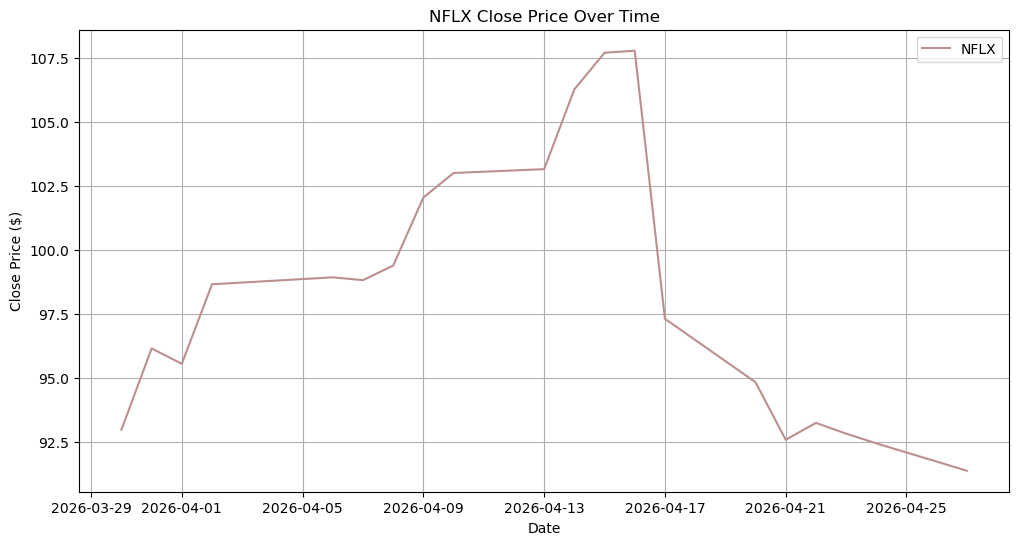

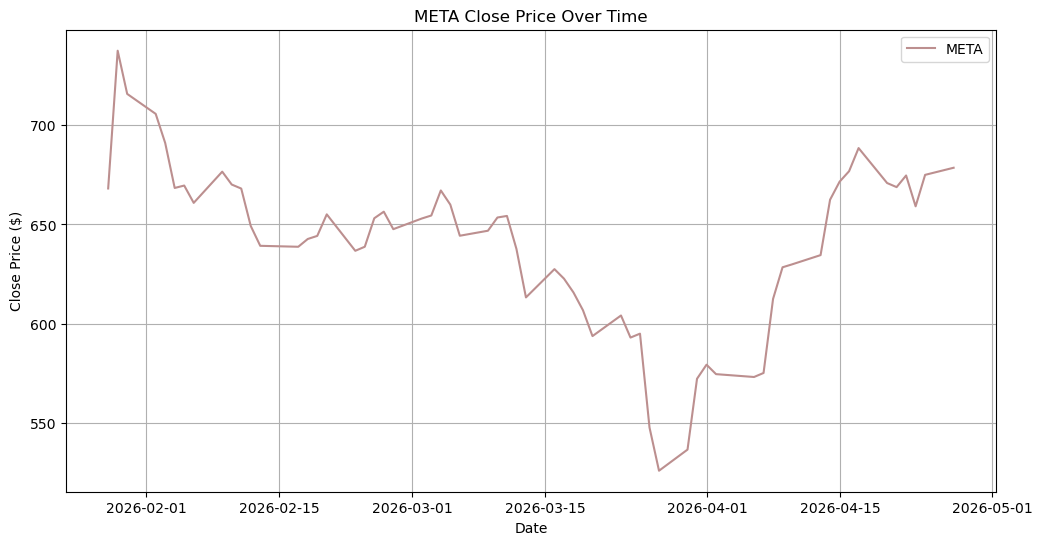

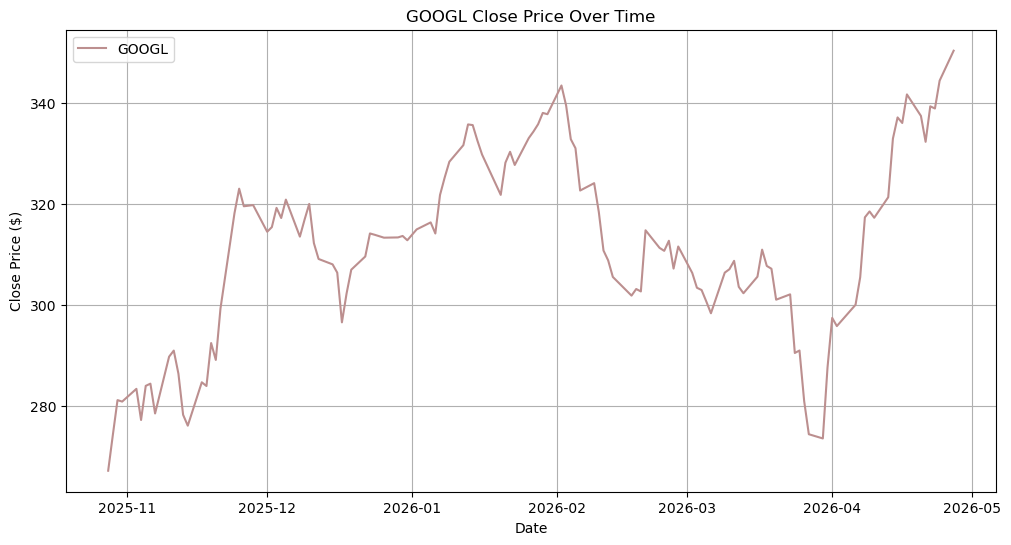

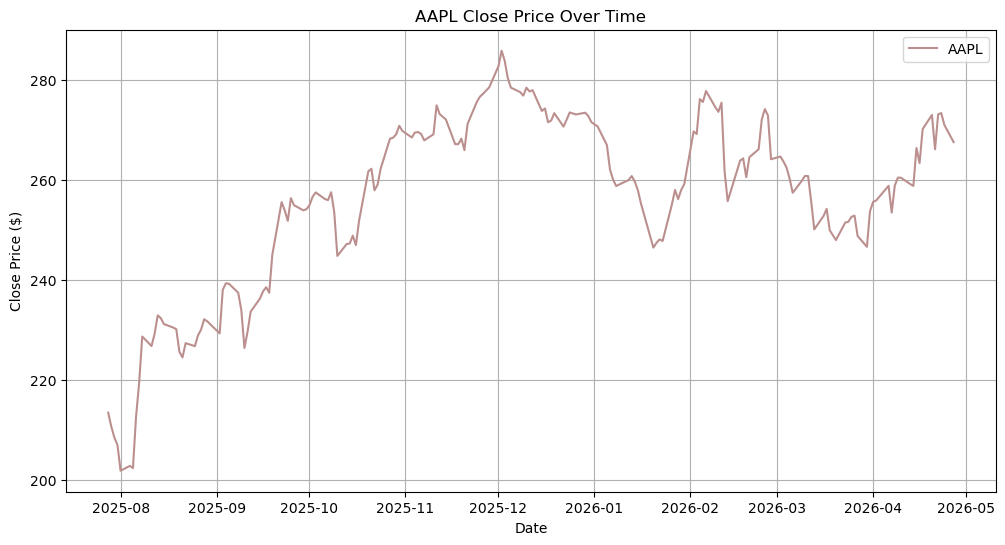

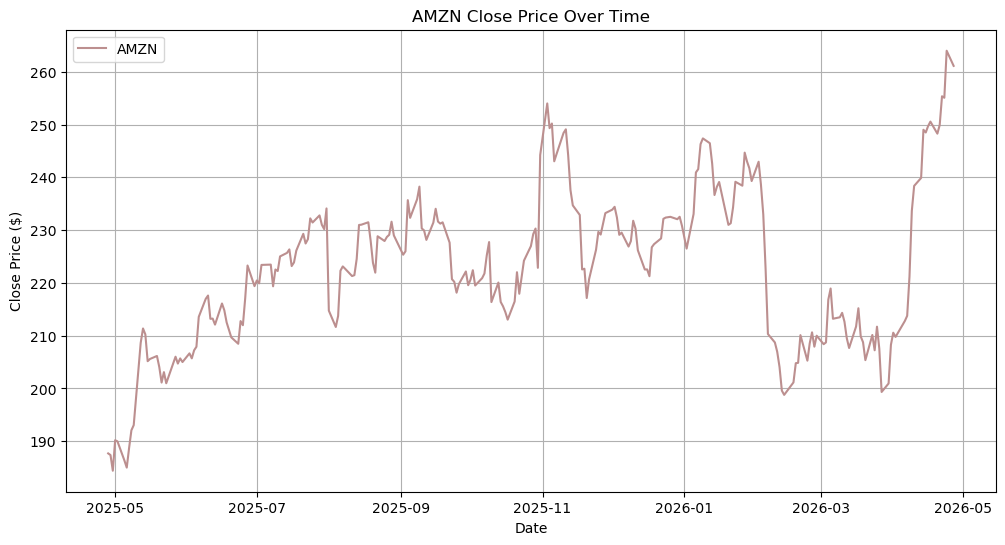

In [40]:
for ticker, df in all_companies.items():

    plt.figure(figsize=(12,6))
    plt.plot(df["Date"], df["Close"], label=ticker, color="rosybrown")

    plt.title(f"{ticker} Close Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price ($)")
    plt.grid(True)
    plt.legend()

    plt.show()


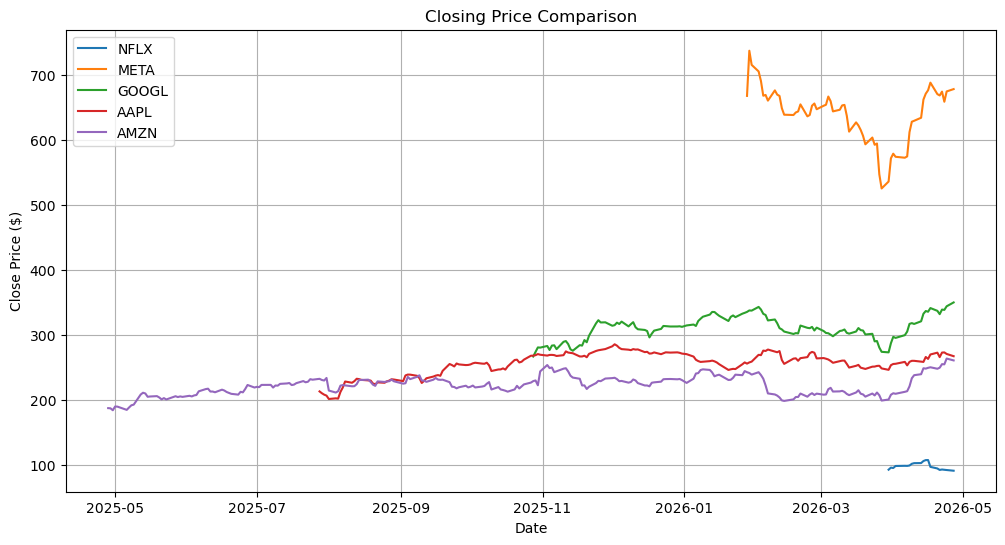

In [41]:
# Comparison chart

plt.figure(figsize=(12,6))

for ticker, df in all_companies.items():
    plt.plot(df["Date"], df["Close"], label=ticker)

plt.title("Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()

plt.show()

In [42]:
!pip install statsmodels

In [43]:
from statsmodels.tsa.stattools import adfuller

In [44]:
# Data is trendy or not

# Perform the Augmented Dickey-Fuller test

#Null hypothesis: The time series is non-stable

for ticker, df in all_companies.items():

    result = adfuller(df["Close"])

    print("\nADF Test for", ticker)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])  


ADF Test for NFLX
ADF Statistic: -0.6957832557197028
p-value: 0.847838748333136

ADF Test for META
ADF Statistic: -1.9036032417874258
p-value: 0.33036793535294506

ADF Test for GOOGL
ADF Statistic: -1.7683102823711943
p-value: 0.39630433621495503

ADF Test for AAPL
ADF Statistic: -2.370942292604712
p-value: 0.15010622065603024

ADF Test for AMZN
ADF Statistic: -2.548288161979596
p-value: 0.10416284193889597


In [45]:
# Interpretation: 
# For every company, the p-value was greater than 0.05, which means stock prices were not stable over time.

In [46]:
#KPIs

In [47]:
# (a) Completeness

for ticker, df in all_companies.items():

    missing_values = df["Close"].isnull().sum()
    total_values = len(df["Close"])

    completeness = ((total_values - missing_values) / total_values) * 100

    print("\n", ticker)
    print("Missing Values:", missing_values)
    print("Completeness %:", round(completeness, 2))


 NFLX
Missing Values: 0
Completeness %: 100.0

 META
Missing Values: 0
Completeness %: 100.0

 GOOGL
Missing Values: 0
Completeness %: 100.0

 AAPL
Missing Values: 0
Completeness %: 100.0

 AMZN
Missing Values: 0
Completeness %: 100.0


In [48]:
#All five datasets have 0 missing values and 100% completeness. 
#This means the data is full and no closing prices are missing.

In [49]:
# (b) Latency

for ticker, df in all_companies.items():

    print("\n", ticker)
    print("Start Date:", df["Date"].min())
    print("Latest Date:", df["Date"].max())


 NFLX
Start Date: 2026-03-30 00:00:00-04:00
Latest Date: 2026-04-27 00:00:00-04:00

 META
Start Date: 2026-01-28 00:00:00-05:00
Latest Date: 2026-04-27 00:00:00-04:00

 GOOGL
Start Date: 2025-10-28 00:00:00-04:00
Latest Date: 2026-04-27 00:00:00-04:00

 AAPL
Start Date: 2025-07-28 00:00:00-04:00
Latest Date: 2026-04-27 00:00:00-04:00

 AMZN
Start Date: 2025-04-28 00:00:00-04:00
Latest Date: 2026-04-27 00:00:00-04:00


In [50]:
#All datasets have recent latest dates. 
#This means the stock data is up to date and suitable for analysis.
#Different start dates match the selected different time periods.

In [51]:
# (c) Accuracy

for ticker, df in all_companies.items():

    negative_prices = (df["Close"] < 0).sum()
    zero_prices = (df["Close"] == 0).sum()

    print("\n", ticker)
    print("Negative Prices:", negative_prices)
    print("Zero Prices:", zero_prices)

    if negative_prices == 0 and zero_prices == 0:
        print("Accuracy: 100%")
    else:
        print("Accuracy issue was observed")


 NFLX
Negative Prices: 0
Zero Prices: 0
Accuracy: 100%

 META
Negative Prices: 0
Zero Prices: 0
Accuracy: 100%

 GOOGL
Negative Prices: 0
Zero Prices: 0
Accuracy: 100%

 AAPL
Negative Prices: 0
Zero Prices: 0
Accuracy: 100%

 AMZN
Negative Prices: 0
Zero Prices: 0
Accuracy: 100%


In [52]:
#All companies have 0 negative prices and 0 zero prices. 
#This means no price errors were found and the data accuracy is high.

In [53]:
# (d) Consistency

for ticker, df in all_companies.items():

    print("\n", ticker)
    print("Columns:", df.columns.tolist())
    print("Date Type:", df["Date"].dtype)
    print("Close Type:", df["Close"].dtype)


 NFLX
Columns: ['Date', 'Close']
Date Type: datetime64[ns, UTC-04:00]
Close Type: float64

 META
Columns: ['Date', 'Close']
Date Type: object
Close Type: float64

 GOOGL
Columns: ['Date', 'Close']
Date Type: object
Close Type: float64

 AAPL
Columns: ['Date', 'Close']
Date Type: object
Close Type: float64

 AMZN
Columns: ['Date', 'Close']
Date Type: object
Close Type: float64


In [54]:
#All datasets use the same columns: Date and Close. 
#Close prices have the same numeric format. 
#Therefore, datasets are consistent and suitable for comparison.